In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

print(sys.executable)

/home/aviraljoshi/mini-logistic-regression/.venv/bin/python3


In [2]:
def toy_loss(w):
    return (w - 3) ** 2

def toy_slope(w):
    return 2 * (w - 3)

w = 0.0
learning_rate = 0.1
history = []

for step in range(25):
    history.append(toy_loss(w))
    w = w - learning_rate * toy_slope(w)

print(history[:3],"...",history[-3:])
print(f"final w = {w:.4f}, final loss = {toy_loss(w):.6f}")

[9.0, 5.76, 3.6864] ... [0.0004900066083661446, 0.0003136042293543294, 0.00020070670678677585]
final w = 2.9887, final loss = 0.000128


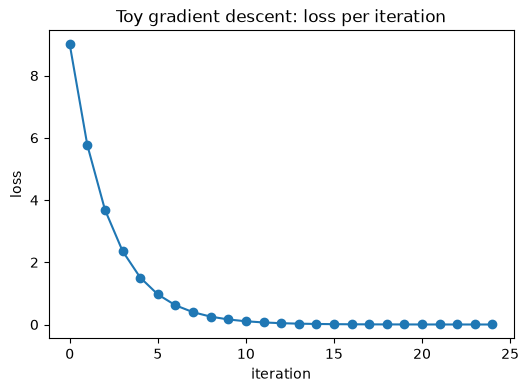

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history, marker="o")
ax.set_xlabel("iteration")
ax.set_ylabel("loss")
ax.set_title("Toy gradient descent: loss per iteration")
plt.show()

In [4]:
def run_toy_gd(learning_rate, n_iterations, w_start=0.0):
    w = w_start
    ws = [w]
    for _ in range(n_iterations):
        w = w - learning_rate * toy_slope(w)
        ws.append(w)
    return ws

ws = run_toy_gd(learning_rate=0.1, n_iterations=25)
print(len(ws))
print(np.round(ws[:4], 3))

26
[0.    0.6   1.08  1.464]


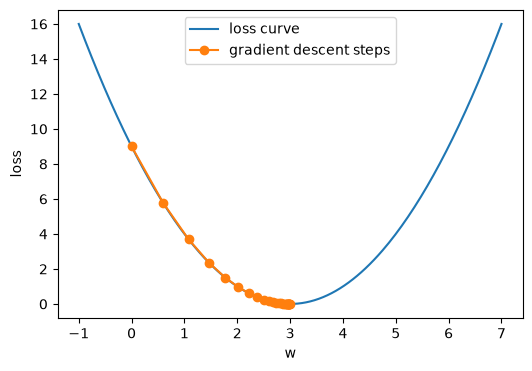

In [5]:
w_grid = np.linspace(-1, 7, 200)
ws_arr = np.array(ws)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(w_grid, toy_loss(w_grid), label="loss curve")  # just to draw a smooth curve
ax.plot(ws_arr, toy_loss(ws_arr), marker="o", label="gradient descent steps")
ax.set_xlabel("w")
ax.set_ylabel("loss")
ax.legend()
plt.show()

## What happens when the learning rate is too small or too big?

The **learning rate** controls how big a step gradient descent takes when updating the parameters.

### Too small (`0.01`)

- The step goes in the **right direction**.
- But the step is very small, so the loss barely changes: `9 → 8.64`.
- We may need **hundreds of iterations** to reach the minimum.
- It's not wrong — just **too slow**.

### About right (`0.1`)

- The step is large enough to make **good progress**.
- The loss decreases at a reasonable rate.
- This gives a good balance between **speed and stability**.

### Too big (`1.1`)

- The step is so large that we **jump over the minimum** (`w = 3`).
- We land farther away on the other side.
- The loss increases: `9 → 12.96`.
- The next gradient can become even larger, causing even bigger jumps.
- The loss keeps increasing instead of decreasing.

This is called **diverging** — the opposite of **converging**.

> **Key idea:**  
> **Learning rate too small → slow convergence**  
> **Learning rate about right → stable convergence**  
> **Learning rate too large → divergence**

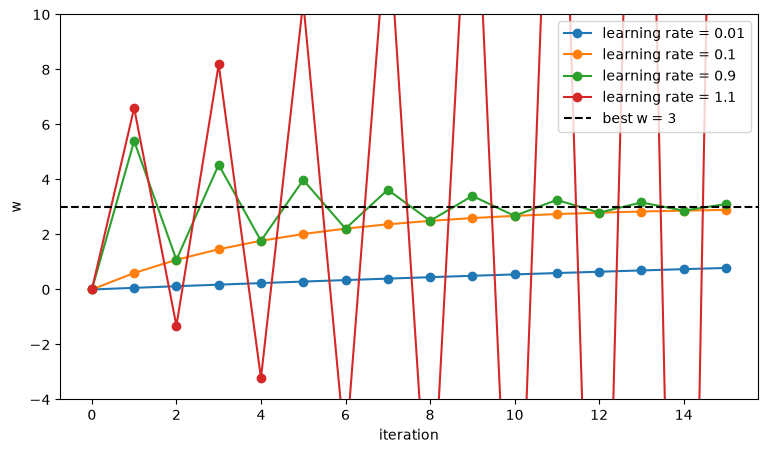

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
for lr in [0.01, 0.1, 0.9, 1.1]:
    ws_lr = run_toy_gd(learning_rate=lr, n_iterations=15)
    ax.plot(ws_lr, marker="o", label=f"learning rate = {lr}")
ax.axhline(3, color="black", linestyle="--", label="best w = 3")
ax.set_ylim(-4, 10)
ax.set_xlabel("iteration")
ax.set_ylabel("w")
ax.legend()
plt.show()

In [7]:
from mini_lr.logistic_regression import LogisticRegression

model_a = LogisticRegression(learning_rate=0.1)
model_b = LogisticRegression(learning_rate=0.01, n_iterations=500)

print(type(model_a))
print(model_a.learning_rate, model_a.n_iterations, model_a.weights_)
print(model_b.learning_rate, model_b.n_iterations, model_b.weights_)

<class 'mini_lr.logistic_regression.LogisticRegression'>
0.1 1000 None
0.01 500 None


In [8]:
X_tiny = np.array([[1.0], [2.0], [3.0], [4.0], [5.0], [6.0]])
y_tiny = np.array([0, 0, 0, 1, 1, 1])

model = LogisticRegression(learning_rate=0.1, n_iterations=1000)
model.fit(X_tiny, y_tiny)

print(len(model.loss_history_))
print(model.loss_history_[0], model.loss_history_[-1])
print(model.weights_, model.bias_)

1000
0.6931471805599453 0.15171378962412982
[1.70361052] -5.690294412813251


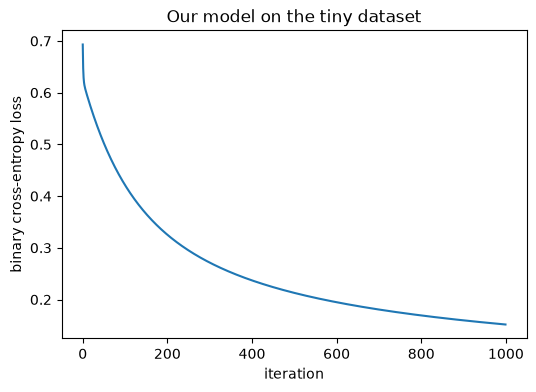

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(model.loss_history_)
ax.set_xlabel("iteration")
ax.set_ylabel("binary cross-entropy loss")
ax.set_title("Our model on the tiny dataset")
plt.show()

In [10]:
model = LogisticRegression(learning_rate=0.1, n_iterations=1000)
model.fit(X_tiny, y_tiny)

proba = model.predict_proba(X_tiny)
preds = model.predict(X_tiny)

print(np.round(proba, 3))
print(preds)
print(proba.shape, preds.dtype)

[0.018 0.093 0.359 0.755 0.944 0.989]
[0 0 0 1 1 1]
(6,) int64


In [11]:
fresh_model = LogisticRegression()

try:
    fresh_model.predict(X_tiny)
except ValueError as err:
    print("Caught the error:", err)

Caught the error: This LogisticRegression is not fitted yet. Call fit(X, y) first.


In [12]:
chain_model = LogisticRegression()
print(chain_model.fit(X_tiny, y_tiny).predict(X_tiny))

returned = chain_model.fit(X_tiny, y_tiny)
print(returned is chain_model)

[0 0 0 1 1 1]
True


In [13]:
print(chain_model)

LogisticRegression(learning_rate=0.1, n_iterations=1000)
